# CITE-seq ADT batch correction benchmark

This executed notebook demonstrates ADT batch correction on the public scvi-tools PBMC10k/PBMC5k CITE-seq tutorial data. It treats antibody-derived tag counts as a cytometry-like marker matrix, runs cyCombinePy on log-transformed ADT values, and compares the result with Harmony and totalVI.

The dataset is `CITE-seq_pbmc_combined_preprocessed.h5mu` from the scvi-tools totalVI tutorial. It contains `rna_subset` and `prot` modalities with a shared `batch` annotation for the two 10x PBMC batches. The Seurat WNN PBMC CITE-seq vignette is a useful conceptual reference, but this notebook uses the Python-native MuData file so the workflow stays in AnnData/MuData objects.

```{note}
Documentation builds render the stored outputs in this notebook, but they do not re-execute it. Running all cells downloads a public file of about 425 MB and trains a small totalVI model. Use `pip install "cycombinepy[benchmark]"` before executing it interactively.
```

## Setup

The benchmark extra installs the heavier optional packages used here:

```bash
pip install "cycombinepy[benchmark]"
```

Set `CYCOMBINEPY_DATA_DIR` to reuse a shared cache location. Set `CYCOMBINEPY_CITESEQ_CELLS_PER_BATCH` to lower the per-batch subset size, and set `TOTALVI_MAX_EPOCHS=2` for a quick smoke test.

In [1]:
from __future__ import annotations

import os
from io import BytesIO
from pathlib import Path
from urllib.request import Request, urlopen

RUNTIME_CACHE = Path(os.environ.get('CYCOMBINEPY_RUNTIME_CACHE', '/tmp/cycombinepy-citeseq-cache')).expanduser()
for name, env_var in {
    'matplotlib': 'MPLCONFIGDIR',
    'xdg': 'XDG_CACHE_HOME',
    'numba': 'NUMBA_CACHE_DIR',
}.items():
    path = RUNTIME_CACHE / name
    path.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault(env_var, str(path))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import Image, display
from scipy import sparse

import cycombinepy
from cycombinepy.correct import CORRECTED_LAYER

SEED = 0
rng = np.random.default_rng(SEED)
sc.set_figure_params(figsize=(4, 4), dpi=90)
sns.set_theme(style='whitegrid')


def _display_figure(fig=None, dpi: int = 120) -> None:
    fig = plt.gcf() if fig is None else fig
    buffer = BytesIO()
    fig.savefig(buffer, format='png', bbox_inches='tight', dpi=dpi)
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


print('cycombinepy', cycombinepy.__version__)

cycombinepy 0.1.2


## Load the PBMC CITE-seq ADT modality

The canonical data path downloads the scvi-tools MuData file once and reuses it from `${CYCOMBINEPY_DATA_DIR:-~/.cache/cycombinepy}`. If `muon`, network access, or the file are unavailable, the helper returns a small synthetic two-batch ADT AnnData so the rest of the notebook can still be read and executed for API checks.

In [2]:
DATA_URL = 'https://exampledata.scverse.org/scvi-tools/CITE-seq_pbmc_combined_preprocessed.h5mu'
DATA_FILENAME = 'CITE-seq_pbmc_combined_preprocessed.h5mu'
DATA_DIR = Path(os.environ.get('CYCOMBINEPY_DATA_DIR', '~/.cache/cycombinepy')).expanduser()
DATA_PATH = DATA_DIR / DATA_FILENAME


def _as_dense(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)


def _download_mudata() -> Path:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    if not DATA_PATH.exists():
        tmp_path = DATA_PATH.with_suffix(DATA_PATH.suffix + '.part')
        request = Request(DATA_URL, headers={'User-Agent': 'cycombinepy-docs/0.1'})
        with urlopen(request, timeout=60) as response, open(tmp_path, 'wb') as f:
            while True:
                chunk = response.read(1024 * 1024)
                if not chunk:
                    break
                f.write(chunk)
        tmp_path.replace(DATA_PATH)
    return DATA_PATH


def _prepare_adt_from_mdata(mdata) -> ad.AnnData:
    adt = mdata.mod["prot"].copy()
    rna_obs = mdata.mod["rna_subset"].obs.reindex(adt.obs_names)
    adt.obs['batch'] = rna_obs['batch'].astype('category')
    if adt.obs['batch'].isna().any():
        raise ValueError('Could not align RNA batch labels to protein cells.')
    for label_key in ('cell_type', 'cell_types', 'celltype', 'celltype.l1', 'celltype.l2', 'labels', 'str_labels'):
        if label_key in rna_obs:
            adt.obs['benchmark_label'] = rna_obs[label_key].astype('category')
            break

    counts = _as_dense(adt.X).astype(float)
    adt.layers['counts'] = counts.copy()
    adt.X = np.log1p(counts)
    adt.var_names_make_unique()
    return adt


def _synthetic_adt(n_per_batch: int = 800, seed: int = SEED) -> ad.AnnData:
    local_rng = np.random.default_rng(seed)
    markers = [
        'CD3', 'CD4', 'CD8', 'CD14', 'CD16', 'CD19', 'CD25', 'CD27',
        'CD45RA', 'CD56', 'CD127', 'CD197', 'HLA-DR', 'IgG1',
    ]
    n_types = 5
    base = local_rng.gamma(shape=2.0, scale=2.0, size=(n_types, len(markers)))
    shifts = [np.ones(len(markers)), np.linspace(0.75, 1.45, len(markers))]
    blocks = []
    labels = []
    batches = []
    for batch_id, shift in enumerate(shifts, start=1):
        cell_types = local_rng.integers(0, n_types, size=n_per_batch)
        lam = base[cell_types] * shift + 0.2
        counts = local_rng.poisson(lam * 8).astype(float)
        blocks.append(counts)
        labels.extend([f'type_{i}' for i in cell_types])
        batches.extend([f'PBMC{batch_id}'] * n_per_batch)
    counts = np.vstack(blocks)
    obs = pd.DataFrame({'batch': batches, 'synthetic_type': labels})
    obs.index = [f'cell_{i}' for i in range(counts.shape[0])]
    out = ad.AnnData(X=np.log1p(counts), obs=obs)
    out.var_names = markers
    out.obs['batch'] = out.obs['batch'].astype('category')
    out.obs['benchmark_label'] = out.obs['synthetic_type'].astype('category')
    out.layers['counts'] = counts.copy()
    return out


def load_citeseq_adt() -> tuple[ad.AnnData, object | None, str]:
    try:
        import muon

        mdata_path = _download_mudata()
        mdata = muon.read_h5mu(mdata_path)
        adt = _prepare_adt_from_mdata(mdata)
        return adt, mdata, f'scvi-tools MuData: {mdata_path}'
    except Exception as exc:
        adt = _synthetic_adt(n_per_batch=800, seed=SEED)
        return adt, None, f'synthetic fallback ({type(exc).__name__})'


adt, mdata, data_source = load_citeseq_adt()
print(data_source)
adt

/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


scvi-tools MuData: /exports/para-lipg-hpc/mdmanurung/_hobby/cyCombinePy/docs/build/citeseq_adt_benchmark/data/CITE-seq_pbmc_combined_preprocessed.h5mu


/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:565: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. 

AnnData object with n_obs × n_vars = 13112 × 17
    obs: 'batch'
    layers: 'counts'

## Subsample and keep the MuData aligned

The full tutorial file has 13,112 cells. The default subset keeps at most 2,500 cells per batch so FlowSOM, Harmony, and totalVI can run on a laptop. The same observation names are used to subset the MuData object before totalVI setup.

In [3]:
TARGET_PER_BATCH = int(os.environ.get('CYCOMBINEPY_CITESEQ_CELLS_PER_BATCH', '2500'))


def _select_by_batch(adata: ad.AnnData, target_per_batch: int, batch_key: str = 'batch') -> list[str]:
    selected = []
    batches = adata.obs[batch_key].astype('category').cat.categories
    for batch in batches:
        names = adata.obs_names[adata.obs[batch_key] == batch].to_numpy()
        if names.size > target_per_batch:
            names = rng.choice(names, size=target_per_batch, replace=False)
        selected.extend(names.tolist())
    return selected


selected_obs = _select_by_batch(adt, TARGET_PER_BATCH)
adt = adt[selected_obs].copy()

mdata_subset = None
if mdata is not None:
    try:
        mdata_subset = mdata[selected_obs, :].copy()
    except Exception:
        mdata_subset = None

adt.obs['batch'] = adt.obs['batch'].astype('category')
print(adt.obs['batch'].value_counts())
adt

batch
5kpbmc     2500
10kpbmc    2500
Name: count, dtype: int64


/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:565: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. 

AnnData object with n_obs × n_vars = 5000 × 17
    obs: 'batch'
    layers: 'counts'

## Uncorrected ADT embedding

The uncorrected reference uses PCA on `log1p(counts)`, then UMAP for visualization. This same PCA matrix is passed to Harmony.

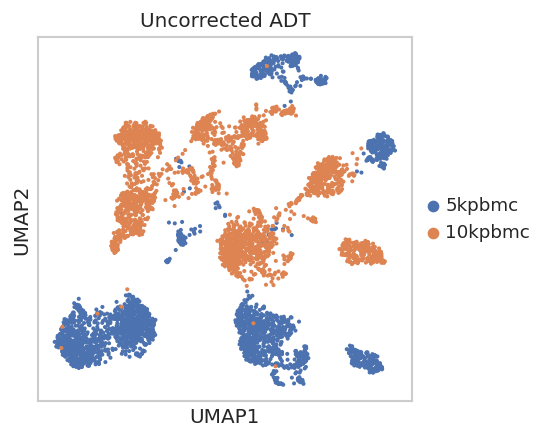

In [4]:
N_PCS = min(15, adt.n_vars - 1, adt.n_obs - 1)
sc.pp.pca(adt, n_comps=N_PCS, random_state=SEED)
adt.obsm['X_pca_uncorrected'] = adt.obsm['X_pca'].copy()
sc.pp.neighbors(adt, use_rep='X_pca_uncorrected', random_state=SEED)
sc.tl.umap(adt, random_state=SEED)
adt.obsm['X_umap_uncorrected'] = adt.obsm['X_umap'].copy()

sc.pl.umap(adt, color='batch', title='Uncorrected ADT', show=False)
_display_figure()

## cyCombinePy ADT correction

For ADT data, keep `layers["counts"]` as the raw matrix and use `adata.X = log1p(counts)` for correction. The SOM is trained on a batch-wise normalized copy in `layers["cycombine_adt_normalized"]`, while ComBat corrects the log-transformed ADT values.

In [5]:
CYCOMBINE_ADT_NORMALIZED = 'cycombine_adt_normalized'

adt.layers[CYCOMBINE_ADT_NORMALIZED] = adt.X.copy()
cycombinepy.normalize(
    adt,
    method='scale',
    batch_key='batch',
    layer=CYCOMBINE_ADT_NORMALIZED,
)
cycombinepy.create_som(
    adt,
    xdim=6,
    ydim=6,
    rlen=5,
    seed=SEED,
    layer=CYCOMBINE_ADT_NORMALIZED,
    label_key='cycombine_som',
)
cycombine_report = cycombinepy.correct_data(
    adt,
    label_key='cycombine_som',
    batch_key='batch',
    layer=None,
    out_layer=CORRECTED_LAYER,
    error_policy='report',
    confound_policy='skip',
    return_report=True,
)

adt_cycombine = adt.copy()
adt_cycombine.X = np.asarray(adt.layers[CORRECTED_LAYER]).copy()
sc.pp.pca(adt_cycombine, n_comps=N_PCS, random_state=SEED)
adt.obsm['X_pca_cycombinepy'] = adt_cycombine.obsm['X_pca'].copy()
if 'benchmark_label' not in adt.obs or adt.obs['benchmark_label'].nunique() < 2:
    adt.obs['benchmark_label'] = adt.obs['cycombine_som'].astype('category')
print('report status:', cycombine_report['status'])
print('SOM clusters:', adt.obs['cycombine_som'].nunique())

/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
2026-07-13 16:35:54.458 | DEBUG    |

2026-07-13 16:35:54.462 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.


2026-07-13 16:35:55.872 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.


report status: completed_with_failures
SOM clusters: 36


## Harmony on ADT PCA

Harmony adjusts a low-dimensional representation rather than marker values. Harmony is embedding-only for this benchmark, so it is included in the embedding metrics but not in expression-layer EMD or MAD.

In [6]:
try:
    import harmonypy

    harmony_result = harmonypy.run_harmony(
        adt.obsm['X_pca_uncorrected'],
        adt.obs,
        'batch',
        max_iter_harmony=20,
    )
    harmony_embedding = np.asarray(harmony_result.Z_corr)
    if harmony_embedding.shape[0] != adt.n_obs:
        harmony_embedding = harmony_embedding.T
    adt.obsm['X_harmony'] = harmony_embedding
    harmony_status = 'ok'
except Exception as exc:
    harmony_status = f'skipped: {type(exc).__name__}'

print('Harmony:', harmony_status)

2026-07-13 16:36:01,513 - harmonypy - INFO - Running Harmony (PyTorch on cpu)


2026-07-13 16:36:01,514 - harmonypy - INFO -   Parameters:


2026-07-13 16:36:01,515 - harmonypy - INFO -     max_iter_harmony: 20


2026-07-13 16:36:01,515 - harmonypy - INFO -     max_iter_kmeans: 20


2026-07-13 16:36:01,516 - harmonypy - INFO -     epsilon_cluster: 1e-05


...

2026-07-13 16:36:04,812 - harmonypy - INFO - Iteration 10 of 20


2026-07-13 16:36:05,009 - harmonypy - INFO - Iteration 11 of 20


2026-07-13 16:36:05,207 - harmonypy - INFO - Iteration 12 of 20


2026-07-13 16:36:05,358 - harmonypy - INFO - Converged after 12 iterations


Harmony: ok


## totalVI latent space and denoised proteins

totalVI models RNA and protein jointly. Here it uses the same subset of the MuData object, with RNA counts from `mdata.mod["rna_subset"].layers["counts"]`, protein values from `mdata.mod["prot"].X`, and batch labels from `mdata.mod["rna_subset"].obs["batch"]`. The latent representation is used for embedding metrics, and denoised protein values are used for expression metrics.

In [7]:
TOTALVI_DENOISED_LAYER = 'totalvi_denoised_protein'
TOTALVI_MAX_EPOCHS = int(os.environ.get('TOTALVI_MAX_EPOCHS', '20'))

try:
    if mdata_subset is None:
        raise RuntimeError('MuData source unavailable')

    import scvi

    scvi.settings.seed = SEED
    mdata_totalvi = mdata_subset.copy()
    mdata_totalvi.mod["prot"].X = _as_dense(mdata_totalvi.mod["prot"].X)
    mdata_totalvi.mod["rna_subset"].X = _as_dense(mdata_totalvi.mod["rna_subset"].X)
    mdata_totalvi.mod["rna_subset"].layers['counts'] = _as_dense(
        mdata_totalvi.mod["rna_subset"].layers['counts']
    )

    scvi.model.TOTALVI.setup_mudata(
        mdata_totalvi,
        rna_layer='counts',
        protein_layer=None,
        batch_key='batch',
        modalities={
            'rna_layer': 'rna_subset',
            'protein_layer': 'prot',
            'batch_key': 'rna_subset',
        },
    )
    totalvi_model = scvi.model.TOTALVI(mdata_totalvi)
    totalvi_model.train(
        max_epochs=TOTALVI_MAX_EPOCHS,
        accelerator='cpu',
        devices=1,
        enable_progress_bar=False,
    )
    adt.obsm['X_totalVI'] = totalvi_model.get_latent_representation()
    _, protein_denoised = totalvi_model.get_normalized_expression(
        n_samples=5,
        return_mean=True,
    )
    if hasattr(protein_denoised, 'to_numpy'):
        protein_denoised = protein_denoised.to_numpy()
    adt.layers[TOTALVI_DENOISED_LAYER] = np.asarray(protein_denoised, dtype=float)
    totalvi_status = 'ok'
except Exception as exc:
    totalvi_status = f'skipped: {type(exc).__name__}'

print('totalVI:', totalvi_status)

Seed set to 0


INFO     Computing empirical prior initialization for protein background.                                          


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


`Trainer.fit` stopped: `max_epochs=20` reached.


totalVI: ok


## Expression and embedding metrics

Expression metrics use EMD and MAD across batches within the cyCombinePy SOM clusters. Embedding metrics use scIB-style metrics from `scib_metrics`: iLISI on nearest-neighbor graphs and batch silhouette within `benchmark_label` groups. Higher iLISI and higher rescaled batch silhouette indicate stronger batch mixing.

In [8]:
def _summarize_expression(adata: ad.AnnData, method: str, layer: str | None) -> dict[str, float | str]:
    emd = cycombinepy.compute_emd(
        adata,
        cell_key='cycombine_som',
        batch_key='batch',
        layer=layer,
    )
    mad = cycombinepy.compute_mad(
        adata,
        cell_key='cycombine_som',
        batch_key='batch',
        layer=layer,
    )
    return {
        'method': method,
        'mean_emd': float(emd['emd'].mean()),
        'median_emd': float(emd['emd'].median()),
        'mean_mad': float(mad['mad'].mean()),
        'median_mad': float(mad['mad'].median()),
    }


def _scib_embedding_metrics(
    embedding: np.ndarray,
    batch: pd.Series,
    labels: pd.Series,
    n_neighbors: int = 30,
) -> dict[str, float | str]:
    from scib_metrics import ilisi_knn, silhouette_batch
    from scib_metrics.nearest_neighbors import pynndescent

    embedding = np.asarray(embedding, dtype=float)
    batch_codes = batch.astype('category').cat.codes.to_numpy()
    label_codes = labels.astype('category').cat.codes.to_numpy()
    if np.unique(batch_codes).size < 2 or embedding.shape[0] < 3:
        return {'scib_ilisi': float('nan'), 'scib_silhouette_batch': float('nan')}

    k = min(n_neighbors, embedding.shape[0] - 1)
    knn = pynndescent(embedding, n_neighbors=k, random_state=SEED, n_jobs=1)
    result = {'scib_ilisi': float(ilisi_knn(knn, batch_codes))}
    if np.unique(label_codes).size > 1:
        result['scib_silhouette_batch'] = float(
            silhouette_batch(embedding, label_codes, batch_codes)
        )
    else:
        result['scib_silhouette_batch'] = float('nan')
    return result


def _summarize_embedding(adata: ad.AnnData, method: str, rep_key: str) -> dict[str, float | str]:
    embedding = np.asarray(adata.obsm[rep_key])
    metrics = _scib_embedding_metrics(
        embedding,
        batch=adata.obs['batch'],
        labels=adata.obs['benchmark_label'],
    )
    return {'method': method, **metrics}


expression_rows = [
    _summarize_expression(adt, 'uncorrected', None),
    _summarize_expression(adt, 'cyCombinePy', CORRECTED_LAYER),
]
if TOTALVI_DENOISED_LAYER in adt.layers:
    expression_rows.append(_summarize_expression(adt, 'totalVI', TOTALVI_DENOISED_LAYER))
expression_table = pd.DataFrame(expression_rows)

embedding_sources = {
    'uncorrected PCA': 'X_pca_uncorrected',
    'cyCombinePy PCA': 'X_pca_cycombinepy',
}
if 'X_harmony' in adt.obsm:
    embedding_sources['Harmony'] = 'X_harmony'
if 'X_totalVI' in adt.obsm:
    embedding_sources['totalVI'] = 'X_totalVI'

embedding_table = pd.DataFrame(
    [_summarize_embedding(adt, method, key) for method, key in embedding_sources.items()]
)
benchmark_table = embedding_table.merge(expression_table, how='outer', on='method')
benchmark_table

,method,scib_ilisi,scib_silhouette_batch,mean_emd,median_emd,mean_mad,median_mad
0,Harmony,0.524235,0.882957,NaN,NaN,NaN,NaN
1,cyCombinePy,NaN,NaN,0.222750,0.140806,0.365316,0.319047
2,cyCombinePy PCA,0.644506,0.970225,NaN,NaN,NaN,NaN
3,totalVI,0.017856,0.752355,119.240587,42.502565,19.143039,5.541317
4,uncorrected,NaN,NaN,1.369962,1.286422,0.370410,0.309837
5,uncorrected PCA,0.000000,0.512470,NaN,NaN,NaN,NaN


## UMAP panels colored by batch

These panels recompute UMAP from each available representation. Use them as a qualitative check next to the compact benchmark table rather than as a standalone proof of biological preservation.

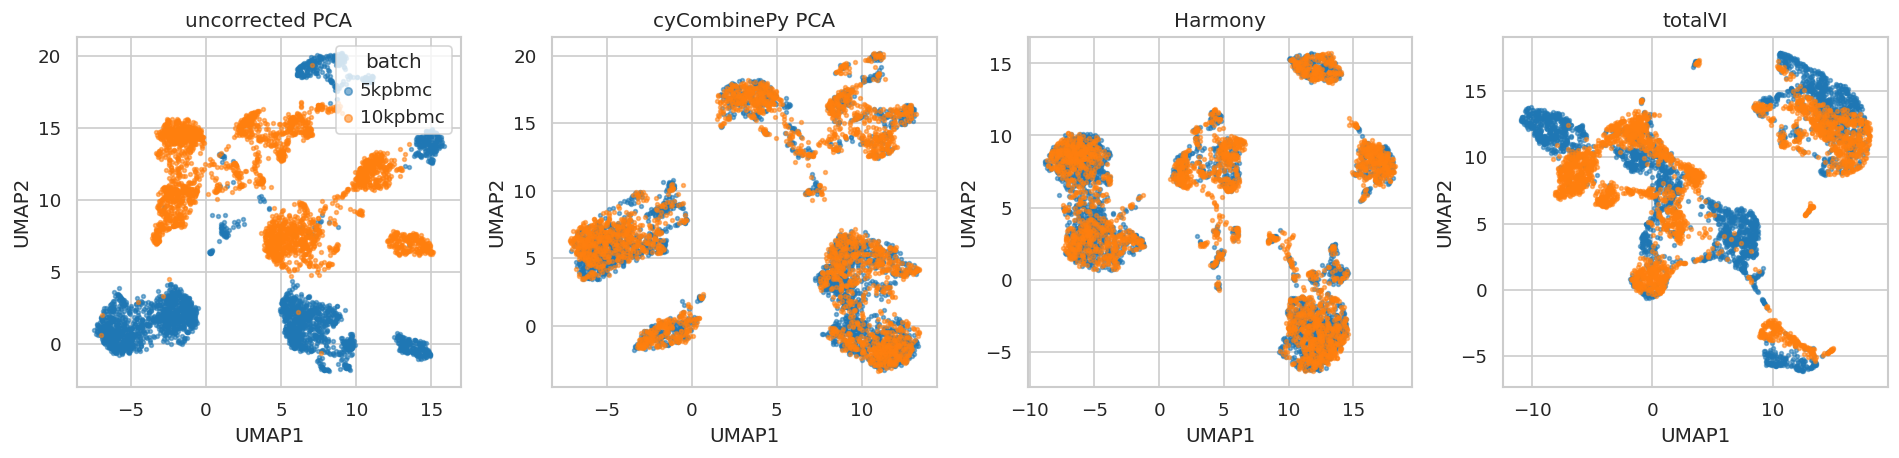

In [9]:
def _umap_from_rep(adata: ad.AnnData, rep_key: str) -> np.ndarray:
    holder = ad.AnnData(X=np.zeros((adata.n_obs, 1)), obs=adata.obs.copy())
    holder.obsm[rep_key] = np.asarray(adata.obsm[rep_key])
    sc.pp.neighbors(holder, use_rep=rep_key, n_neighbors=15, random_state=SEED)
    sc.tl.umap(holder, random_state=SEED)
    return holder.obsm['X_umap']


umap_panels = []
for method, rep_key in embedding_sources.items():
    umap_panels.append((method, _umap_from_rep(adt, rep_key)))

batch_codes = adt.obs['batch'].astype('category').cat.codes.to_numpy()
palette = sns.color_palette('tab10', n_colors=adt.obs['batch'].nunique())
fig, axes = plt.subplots(1, len(umap_panels), figsize=(4 * len(umap_panels), 4), squeeze=False)
for ax, (method, coords) in zip(axes.ravel(), umap_panels):
    for code, batch_name in enumerate(adt.obs['batch'].astype('category').cat.categories):
        mask = batch_codes == code
        ax.scatter(coords[mask, 0], coords[mask, 1], s=5, alpha=0.55, label=batch_name, color=palette[code])
    ax.set_title(method)
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
axes.ravel()[0].legend(title='batch', loc='best', markerscale=2)
fig.tight_layout()
_display_figure(fig)

## Interpreting the table

- `uncorrected` and `cyCombinePy` can be compared directly on EMD and MAD because both are ADT expression matrices.
- `totalVI` contributes both a latent space and denoised protein values when the benchmark dependencies and MuData source are available.
- `Harmony` contributes only `X_harmony`. It is omitted from EMD and MAD because it does not produce corrected ADT expression values in this workflow.
- The scIB-style embedding metrics are `scib_ilisi` and `scib_silhouette_batch`. They measure batch mixing in the selected representation.
- These metrics measure batch mixing and ADT distribution alignment. They do not establish that one method is biologically superior for every downstream analysis.